In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from datetime import datetime, timedelta
import datajoint as dj

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
from workflow.pipeline import frame, culture, ephys, analysis, mua, probe

[2026-01-16 11:59:21,127][INFO]: DataJoint 0.14.4 connected to judewerth@db.datajoint.com:3306


Module stfio is not installed. Make sure .abf files are converted to .pkl in Python 2.


# This Notebook is designed to conduct complete and thurough analysis of a single session.

The expectation is that all data is already processed. View ____ for data processing steps.

In [102]:
key = {
    'organoid_id': 'O09', 
    'experiment_start_time': datetime(2023, 5, 3, 17, 33), 
    'insertion_number': 0, 
    'start_time': datetime(2023, 5, 4, 4, 12, 52), 
    'end_time': datetime(2023, 5, 4, 4, 27, 52)
}

num_elec_inside = (frame.NumElectrodesInside & key).fetch1('num_electrodes')

ephys.EphysSession & key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,session_type
O09,2023-05-03 17:33:00,0,2023-05-04 04:12:52,2023-05-04 04:27:52,both


## Spike Actvity

MUA
- MUASpikes
    - Firing rate
    - Spike times
    - Spike amplitudes
    - Noise levels (mean absolute derivation)
- MUATracePlot
    - High-pass filtered traces with spike times overlaid
- PopulationBursts
    - Burst indices
    - Peak burst height
    - Burst duration (>10% of peak)
    - Electrode spike times during bursts

In [13]:
# MUA activity is processed per file, not per session. So we need to get the file keys for this session.
mua_keys = (mua.MUAEphysSession & f"organoid_id = '{key['organoid_id']}'" & f"start_time BETWEEN '{key['start_time']}' AND '{key['end_time']-timedelta(seconds=1)}'").fetch("KEY")
mua.MUAEphysSession & mua_keys

organoid_id e.g. O17,experiment_start_time,start_time,end_time,"port_id e.g. A, B, C, ..."
O09,2023-05-03 17:33:00,2023-05-04 04:12:52,2023-05-04 04:13:52,A
O09,2023-05-03 17:33:00,2023-05-04 04:13:52,2023-05-04 04:14:52,A
O09,2023-05-03 17:33:00,2023-05-04 04:14:52,2023-05-04 04:15:52,A
O09,2023-05-03 17:33:00,2023-05-04 04:15:52,2023-05-04 04:16:52,A
O09,2023-05-03 17:33:00,2023-05-04 04:16:52,2023-05-04 04:17:52,A
O09,2023-05-03 17:33:00,2023-05-04 04:17:52,2023-05-04 04:18:52,A
O09,2023-05-03 17:33:00,2023-05-04 04:18:52,2023-05-04 04:19:52,A
O09,2023-05-03 17:33:00,2023-05-04 04:19:52,2023-05-04 04:20:52,A
O09,2023-05-03 17:33:00,2023-05-04 04:20:52,2023-05-04 04:21:52,A
O09,2023-05-03 17:33:00,2023-05-04 04:21:52,2023-05-04 04:22:52,A


In [23]:
# MUA Sessions are not automatically mapped to electrode indices, so we need to do that here.
def map_channel_to_electrode(channel_ids):

    electrode_mapping, channel_mapping = probe.ElectrodeConfig.Electrode.fetch("electrode", "channel_idx")

    # create lookup to convert
    lookup = np.empty(32, dtype=int)
    lookup[channel_mapping] = electrode_mapping

    # correctly map electrode indices
    electrode_ids = lookup[channel_ids]
    
    return electrode_ids

Investigate MUA Traces (do later)

Investigate MUA Firing Rates

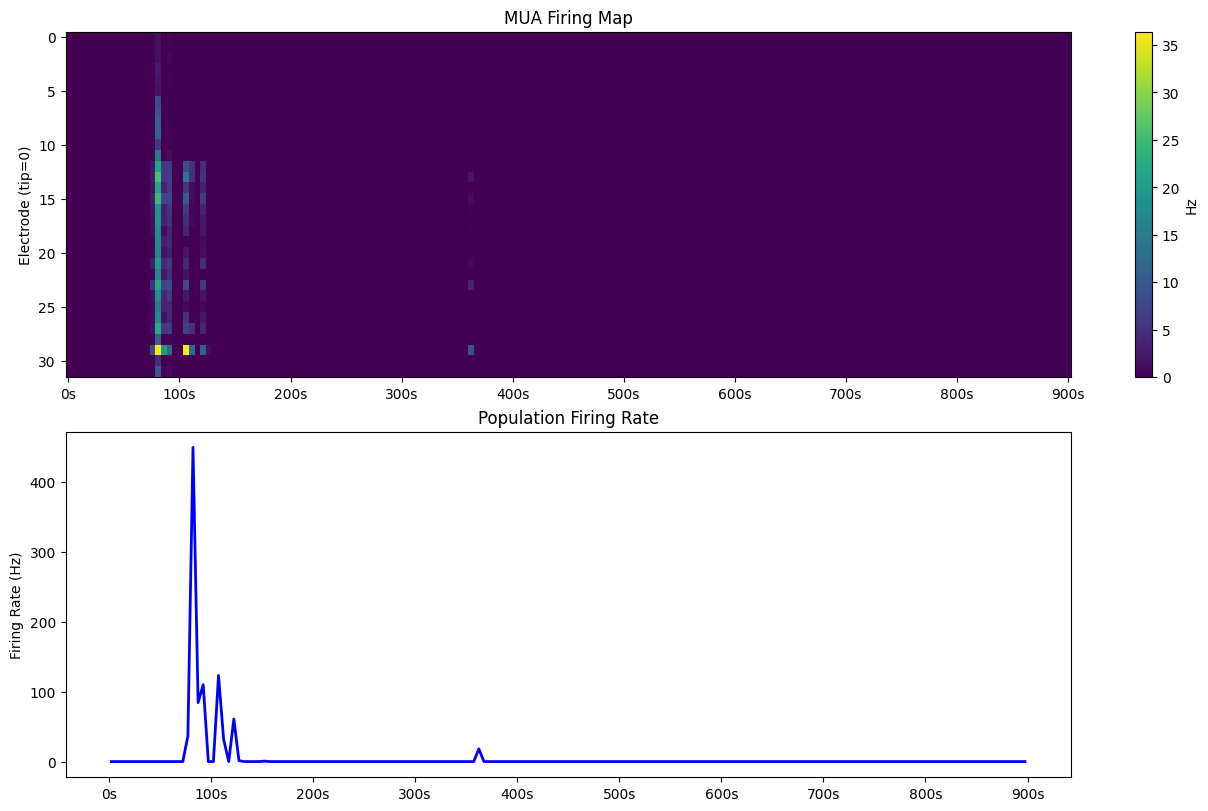

In [103]:
# Plot 2x1 figure with firing map and population firing rate
fs = 20000  # sampling rate
dt = 5 # bin size (seconds)

# fetch data
channel_ids, start_times, spike_indices = (mua.MUASpikes.Channel & mua_keys).fetch("channel_idx", "start_time", "spike_indices")
electrode_ids = map_channel_to_electrode(channel_ids)

# get spike arrays binned at dt
T = int((key['end_time'] - key['start_time']).total_seconds())
time_bins = np.arange(0, T+dt, dt)
spike_array = np.zeros((len(np.unique(electrode_ids)), len(time_bins)-1))
list1 = []
for el_id, st_time, spk_idx in zip(electrode_ids, start_times, spike_indices):
    # convert spike indices to times in seconds
    spike_times = spk_idx / fs + (st_time - key['start_time']).total_seconds()

    # bin spikes
    if len(spike_times) > 0:
        spike_counts, _ = np.histogram(spike_times, bins=time_bins)
        spike_array[el_id, :] += spike_counts / dt  # convert to firing rate (Hz)

# remove electrodes outside of the organoid
spike_array = spike_array[:num_elec_inside, :]

# get population firing rate
population_firing_rate = np.sum(spike_array, axis=0)

# plot figure
fig, axs = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)
num_xticks = 10

# plot firing map
im = axs[0].imshow(spike_array, aspect='auto', cmap='viridis')
axs[0].set_title('MUA Firing Map')
axs[0].set_ylabel('Electrode (tip=0)')
axs[0].set_xticks(np.linspace(0, len(time_bins)-2, num_xticks))
axs[0].set_xticklabels([f"{int(t)}s" for t in np.linspace(0, T, num_xticks)])
fig.colorbar(im, ax=axs[0], label='Hz')

# plot population firing rate
t = (time_bins[:-1] + time_bins[1:]) / 2
axs[1].plot(t, population_firing_rate, color='blue', linewidth=2)
axs[1].set_title('Population Firing Rate')
axs[1].set_ylabel('Firing Rate (Hz)')
axs[1].set_xticks(np.arange(0, T+1, T/(num_xticks-1)))
axs[1].set_xticklabels([f"{int(t)}s" for t in np.linspace(0, T, num_xticks)])

plt.show()

Investigate Spike Characteristics (ISI and Amplitude)

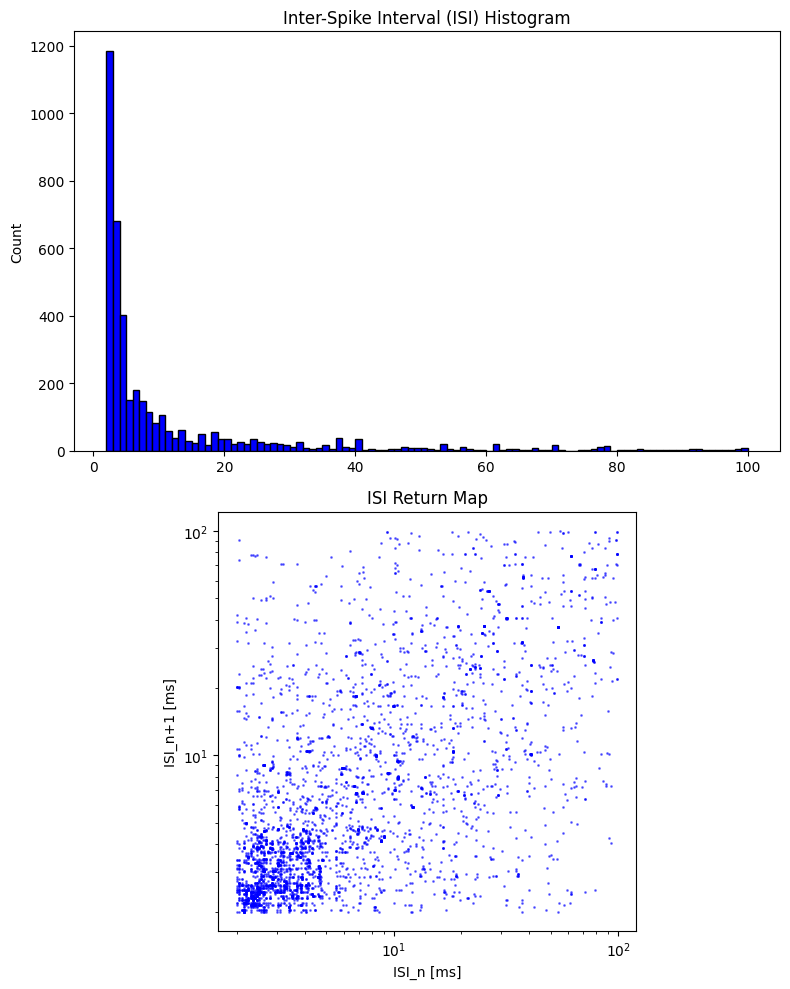

In [ ]:
# Plot 2 figures (1 for ISI, 1 for spike amplitudes)
fs = 20000  # sampling rate
isi_min = 2 # min isi to consider (ms)
isi_max = 100 # max isi to consider (ms)

# fetch data
channel_ids, start_times, spike_indices, spike_amplitudes = (mua.MUASpikes.Channel & mua_keys).fetch("channel_idx", "start_time", "spike_indices", "spike_amp")
electrode_ids = map_channel_to_electrode(channel_ids)

# get isis and spike amplitudes per electrode
elec_spike_times = [[] for _ in range(len(np.unique(electrode_ids)))]
elec_spike_amp = [[] for _ in range(len(np.unique(electrode_ids)))]
for el_id, st_time, spk_idx, spk_amp in zip(electrode_ids, start_times, spike_indices, spike_amplitudes):
    # convert spike indices to times in seconds
    spike_times = spk_idx / fs + (st_time - key['start_time']).total_seconds()
    spike_times *= 1000  # convert to ms
    
    elec_spike_times[el_id].extend(spike_times)
    elec_spike_amp[el_id].extend(spk_amp)

# remove electrodes outside of the organoid
elec_spike_times = elec_spike_times[:num_elec_inside]
elec_spike_amp = elec_spike_amp[:num_elec_inside]

# get total isis and spike amplitudes
elec_spike_isi = np.array([np.diff(np.sort(el_spk_times)) for el_spk_times in elec_spike_times], dtype=object)
spike_isi = np.hstack(elec_spike_isi)
spike_amplitudes = np.hstack(elec_spike_amp)

# create return map
isi_n = []
isi_n_plus_1 = []
for el_isi in elec_spike_isi:
    el_isi = el_isi[(el_isi >= isi_min) & (el_isi <= isi_max)] # filter isi
    isi_n.extend(el_isi[:-1])
    isi_n_plus_1.extend(el_isi[1:])


# plot figures 

# isi plot (top subplot is a ISI histogram, bottom subplot is a ISI return map (share x axis))
fig, axs = plt.subplots(2, 1, figsize=(8, 10))

# histogram
bins = np.arange(isi_min, isi_max+1, 1)
axs[0].hist(spike_isi, bins=bins, color='blue', edgecolor='black')
axs[0].set_title('Inter-Spike Interval (ISI) Histogram')
axs[0].set_ylabel('Count')

# return map 
axs[1].scatter(isi_n, isi_n_plus_1, s=1, color='blue', alpha=0.5)
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_title('ISI Return Map')
axs[1].set_xlabel('ISI_n [ms]')
axs[1].set_ylabel('ISI_n+1 [ms]')

# make the bottom plot square while keeping x-axis aligned
axs[1].set_aspect('equal', adjustable='box')
fig.tight_layout()



plt.show()

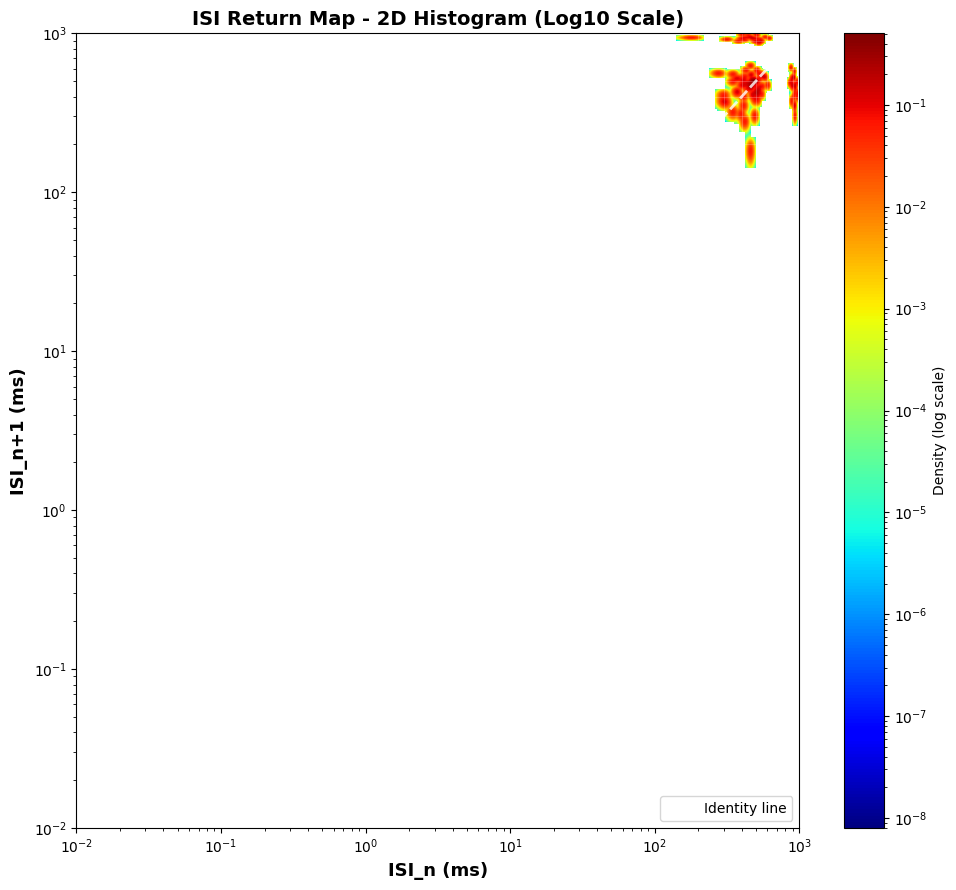

In [199]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm

def plot_isi_return_map_2d_logscale(isi_n, isi_n_plus_1, 
                                     bins_per_decade=20,
                                     sigma=2,
                                     use_log_colorscale=True,
                                     figsize=(10, 9)):
    """
    Create a 2D histogram ISI return map with logarithmic scaling.
    
    Parameters
    ----------
    isi_n : array-like
        ISI values at position n
    isi_n_plus_1 : array-like
        ISI values at position n+1
    bins_per_decade : int
        Number of bins per order of magnitude (default: 20)
    sigma : float
        Gaussian smoothing parameter (default: 2)
    use_log_colorscale : bool
        If True, apply logarithmic normalization to color intensity
    figsize : tuple
        Figure dimensions
        
    Returns
    -------
    fig : matplotlib.figure.Figure
        The generated figure
    H_smooth : ndarray
        Smoothed 2D histogram
    """
    # Step 1: Remove invalid values (zeros and negatives)
    valid_mask = (isi_n > 0) & (isi_n_plus_1 > 0)
    isi_n_valid = isi_n[valid_mask]
    isi_n_plus_1_valid = isi_n_plus_1[valid_mask]
    
    if len(isi_n_valid) < 10:
        raise ValueError("Insufficient valid data points after filtering")
    
    # Step 2: Create logarithmic bin edges
    # Determine the range in log10 space
    xmin = np.floor(np.log10(np.min(isi_n_valid)))
    xmax = np.ceil(np.log10(np.max(isi_n_valid)))
    ymin = np.floor(np.log10(np.min(isi_n_plus_1_valid)))
    ymax = np.ceil(np.log10(np.max(isi_n_plus_1_valid)))
    
    # Calculate number of bins
    x_decades = int(xmax - xmin)
    y_decades = int(ymax - ymin)
    n_xbins = bins_per_decade * x_decades
    n_ybins = bins_per_decade * y_decades
    
    # Create logarithmically spaced bins
    xbins = np.logspace(xmin, xmax, n_xbins + 1)
    ybins = np.logspace(ymin, ymax, n_ybins + 1)
    
    # Step 3: Create 2D histogram with logarithmic bins
    H, xedges, yedges = np.histogram2d(isi_n_valid, isi_n_plus_1_valid, 
                                        bins=[xbins, ybins])
    
    # Step 4: Apply Gaussian smoothing
    # Note: smoothing in log-space requires careful sigma selection
    H_smooth = gaussian_filter(H, sigma=sigma)
    
    # Step 5: Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Choose normalization
    if use_log_colorscale:
        # Logarithmic color normalization
        # Add small value to avoid log(0)
        H_plot = H_smooth.T
        H_plot[H_plot == 0] = np.nan  # Set zeros to NaN to exclude from colormap
        
        # Get min/max for color scale (excluding zeros)
        vmin = np.nanmin(H_plot[H_plot > 0]) if np.any(H_plot > 0) else 1
        vmax = np.nanmax(H_plot)
        
        im = ax.imshow(H_plot, 
                       origin='lower', 
                       aspect='auto',
                       cmap='jet', 
                       interpolation='gaussian',
                       extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                       norm=LogNorm(vmin=vmin, vmax=vmax))
        
        cbar = plt.colorbar(im, ax=ax, label='Density (log scale)')
    else:
        # Linear color normalization
        im = ax.imshow(H_smooth.T, 
                       origin='lower', 
                       aspect='auto',
                       cmap='jet', 
                       interpolation='gaussian',
                       extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
        
        cbar = plt.colorbar(im, ax=ax, label='Density')
    
    # Step 6: Set logarithmic scales for both axes
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Step 7: Add identity line
    min_val = max(xedges[0], yedges[0])
    max_val = min(xedges[-1], yedges[-1])
    ax.plot([min_val, max_val], [min_val, max_val], 
            'w--', linewidth=2, alpha=0.8, label='Identity line')
    
    # Step 8: Formatting
    ax.set_xlabel('ISI_n (ms)', fontsize=13, fontweight='bold')
    ax.set_ylabel('ISI_n+1 (ms)', fontsize=13, fontweight='bold')
    ax.set_title('ISI Return Map - 2D Histogram (Log10 Scale)', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both', color='white', linewidth=0.5)
    ax.legend(loc='lower right', fontsize=10)
    
    # Set axis limits explicitly
    ax.set_xlim(xedges[0], xedges[-1])
    ax.set_ylim(yedges[0], yedges[-1])
    
    plt.tight_layout()
    
    return fig, H_smooth


# Example usage with bursting neuron data
np.random.seed(42)

# Generate bursting spike train
spike_times = []
current_time = 0
for _ in range(25):
    # Within-burst spikes
    n_spikes = np.random.randint(3, 7)
    burst_isis = np.random.gamma(2, 1.5, n_spikes)
    for isi in burst_isis:
        current_time += isi
        spike_times.append(current_time)
    
    # Inter-burst interval
    current_time += np.random.lognormal(np.log(400), 0.5)

spike_times = np.array(spike_times)
isi = np.diff(spike_times)
isi_n = isi[:-1]
isi_n_plus_1 = isi[1:]

# Generate the log-scale 2D histogram
fig, H_smooth = plot_isi_return_map_2d_logscale(isi_n, isi_n_plus_1,
                                                 bins_per_decade=25,
                                                 sigma=1.5,
                                                 use_log_colorscale=True)
plt.show()


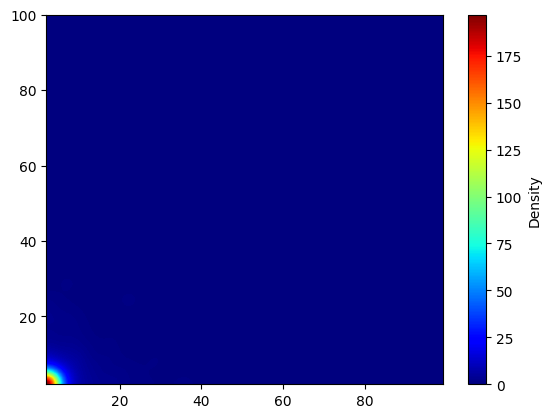

In [185]:

from scipy.ndimage import gaussian_filter

# Create 2D histogram
H, xedges, yedges = np.histogram2d(isi_n, isi_n_plus_1, bins=100)

# Apply Gaussian smoothing
H_smooth = gaussian_filter(H, sigma=2)

# Plot
plt.imshow(H_smooth.T, origin='lower', aspect='auto', 
           cmap='jet', interpolation='gaussian',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
plt.colorbar(label='Density')